In [ ]:
import numpy as np

GM = 3.986e14
R = 6371000

def orbital_velocity(altitude_m):
    return np.sqrt(GM / (R + altitude_m))

In [ ]:
def altitude_loss(altitude_m, dt):
    rho = 1.225 * np.exp(-altitude_m / 8500)
    v = orbital_velocity(altitude_m)
    drag = 0.5 * rho * v**2 * 2.2 * 0.03
    deceleration = drag / 4.0
    return deceleration * dt * 200000

In [ ]:
altitude = 400000  # 400km in meters
dt = 60            # one minute timestep
time_days = []
altitudes_km = []
elapsed_seconds = 0

while altitude > 80000:
    altitude -= altitude_loss(altitude, dt)
    elapsed_seconds += dt
    time_days.append(elapsed_seconds / 86400)
    altitudes_km.append(altitude / 1000)
    if elapsed_seconds > 50 * 365 * 86400:  # 50 year cutoff
      break

print(f"Re-entry after {elapsed_seconds/86400:.1f} days")

Re-entry after 18250.0 days


/tmp/ipykernel_9106/2325979151.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("Altitude Over Time", dpi= 150, bbox_inches = 'tight')


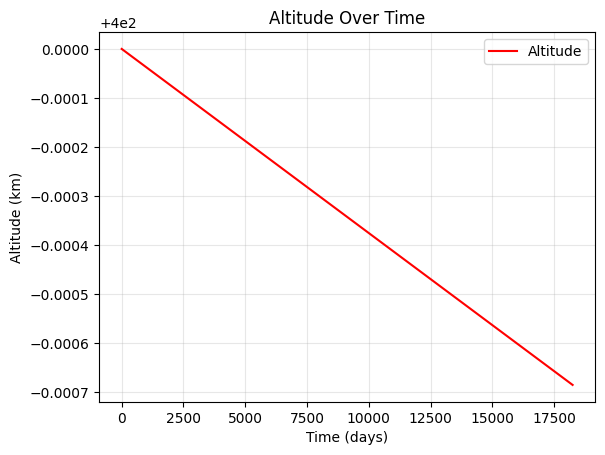

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(time_days, altitudes_km, label = "Altitude", color = "red")
plt.legend()
plt.xlabel('Time (days)')
plt.ylabel('Altitude (km)')
plt.title('Altitude Over Time')
plt.grid(True, alpha = 0.3)
plt.savefig("Altitude Over Time", dpi= 150, bbox_inches = 'tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

GM = 3.986e14
R = 6371000

def orbital_velocity(altitude_m):
    return np.sqrt(GM / (R + altitude_m))

def atmospheric_density(altitude_m):
    return 1.225 * np.exp(-altitude_m / 8500)

def altitude_loss(altitude_m, dt):
    rho = atmospheric_density(altitude_m)
    v = orbital_velocity(altitude_m)
    drag = 0.5 * rho * v**2 * 2.2 * 0.03
    deceleration = drag / 4.0
    # Energy method: altitude loss from orbital mechanics
    delta_v = deceleration * dt
    delta_h = (2 * (R + altitude_m) * delta_v) / v
    return delta_h

altitude = 400000.0
dt = 3600  # one hour timestep instead of 60 seconds
time_days = []
altitudes_km = []
elapsed_seconds = 0

while altitude > 80000:
    loss = altitude_loss(altitude, dt)
    altitude -= loss
    elapsed_seconds += dt
    time_days.append(elapsed_seconds / 86400)
    altitudes_km.append(altitude / 1000)

print(f"Re-entry after {elapsed_seconds/86400:.1f} days")

plt.figure(figsize=(10, 6))
plt.plot(time_days, altitudes_km, color='navy', linewidth=2)
plt.xlabel('Time (days)')
plt.ylabel('Altitude (km)')
plt.title('CubeSat Orbital Decay — LEO to Re-entry')
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()
plt.savefig('orbital_decay.png', dpi=150, bbox_inches='tight')
plt.show()

In [1]:
loss = altitude_loss(400000, 3600)
print(f"Loss per hour: {loss:.8f} meters")
print(f"Loss per day: {loss*24:.4f} meters")
print(f"Loss per year: {loss*24*365:.2f} meters")

NameError: name 'altitude_loss' is not defined

In [2]:
max_years = 20
max_steps = int(max_years * 365 * 24)  # 20 years of hourly steps

step = 0
while altitude > 80000 and step < max_steps:
    loss = altitude_loss(altitude, dt)
    if loss <= 0:
        print("Drag too weak, check parameters")
        break
    altitude -= loss
    elapsed_seconds += dt
    time_days.append(elapsed_seconds / 86400)
    altitudes_km.append(altitude / 1000)
    step += 1

print(f"Final altitude: {altitude/1000:.1f} km")
print(f"Elapsed: {elapsed_seconds/86400:.1f} days")
print(f"Steps completed: {step}")

NameError: name 'altitude' is not defined